In [ ]:
import tqdm
from numpy.typing import NDArray
import numpy as np
from pathlib import Path
import cv2


class ImageDataset:
    def __init__(self, folder_path: Path):
        self.folder_path = folder_path
        self.image_paths = self._load_image_paths()
        self.descriptors: dict[str, NDArray[np.float32]] = {}

    def _load_image_paths(self):
        return {
            filename.name: filename
            for filename in self.folder_path.glob('*.jpg')
        }

    def compute_sift_descriptors(self):
        sift = cv2.SIFT_create()
        for name, path in tqdm.tqdm(self.image_paths.items()):
            img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE) 
            if img is not None:
                _, desc = sift.detectAndCompute(img, None)
                self.descriptors[name] = desc

In [11]:
index_params = dict(algorithm=1, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)


def match_descriptors(desc1, desc2):
    
    matches = flann.knnMatch(desc1, desc2, k=2)    
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)
    
    return good_matches

In [2]:
VAL_DATASET_PATH = Path('data/test')
TRAIN_DATASET_PATH = Path('data/train')

val_dataset = ImageDataset(VAL_DATASET_PATH)
train_dataset = ImageDataset(TRAIN_DATASET_PATH)

val_dataset.compute_sift_descriptors()
train_dataset.compute_sift_descriptors()

  0%|          | 0/328 [00:00<?, ?it/s]

100%|██████████| 827/827 [02:35<00:00,  5.32it/s]


Сравнивать каждый дескрипшн из val с дескрипшеном из train нереально долго, так как это больше чем n^2 задача. Поэтому я решил немного отфильтровать ну уж совсем разные изображения с помощью хешей

In [20]:
import tqdm
import imagehash
from PIL import Image


val_hashes = {
    name: imagehash.phash(Image.open(val_dataset.image_paths[name]))
    for name in tqdm.tqdm(val_dataset.image_paths)
}

train_hashes = {
    name: imagehash.phash(Image.open(train_dataset.image_paths[name]))
    for name in tqdm.tqdm(train_dataset.image_paths)
}

hash_diff = []

for val_img_name, val_desc in tqdm.tqdm(val_dataset.descriptors.items()):
    val_hash = val_hashes[val_img_name]

    for train_img_name, train_desc in train_dataset.descriptors.items():
        train_hash = train_hashes[train_img_name]

        hash_diff.append(val_hash - train_hash)

100%|██████████| 328/328 [00:00<00:00, 746.99it/s]


Найду распределение разницы хешей, чтобы лучше понять какой hash_threshold взять 

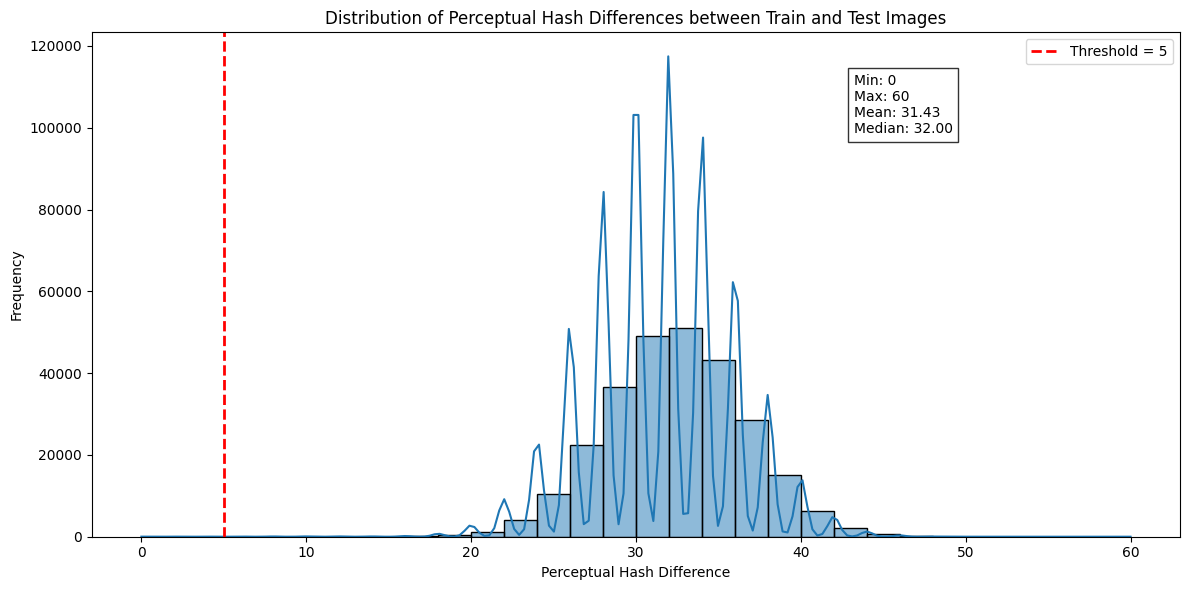

Number of image pairs with hash difference < 5: 31 out of 271256 (0.01%)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Calculate the histogram of hash differences
plt.figure(figsize=(12, 6))

hash_diff_array = np.array(hash_diff)
sns.histplot(hash_diff_array, bins=30, kde=True)
plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label=f'Threshold = 5')
plt.xlabel('Perceptual Hash Difference')
plt.ylabel('Frequency')
plt.title('Distribution of Perceptual Hash Differences between Train and Test Images')
plt.legend()

# Add some statistics as text
plt.text(0.7, 0.8, 
         f'Min: {hash_diff_array.min()}\nMax: {hash_diff_array.max()}\nMean: {hash_diff_array.mean():.2f}\nMedian: {np.median(hash_diff_array):.2f}',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Also print the percentage of pairs below the threshold
below_threshold = (hash_diff_array < 5).sum()
total_pairs = len(hash_diff_array)
percentage = (below_threshold / total_pairs) * 100

print(f"Number of image pairs with hash difference < 5: {below_threshold} out of {total_pairs} ({percentage:.2f}%)")

In [37]:
(hash_diff_array < 22).sum()

np.int64(1777)

In [35]:
threshold = 15
hash_threshold = 22
dublicates = []

for val_img_name, val_desc in tqdm.tqdm(val_dataset.descriptors.items()):
    val_hash = val_hashes[val_img_name]

    for train_img_name, train_desc in train_dataset.descriptors.items():
        train_hash = train_hashes[train_img_name]

        if val_hash - train_hash < hash_threshold:
            good_matches = match_descriptors(val_desc, train_desc)
            if len(good_matches) >= threshold:
                dublicates.append((val_img_name, train_img_name))


100%|██████████| 328/328 [03:35<00:00,  1.52it/s]


In [40]:
import csv
import pandas as pd

df_duplicates = pd.DataFrame(dublicates, columns=['test_image', 'train_image'])

duplicate_info = []
for val_img_name, train_img_name in tqdm.tqdm(dublicates):
    val_hash = val_hashes[val_img_name]
    train_hash = train_hashes[train_img_name]
    hash_difference = val_hash - train_hash
    
    
    duplicate_info.append({
        'test_image': val_img_name,
        'train_image': train_img_name,
        'hash_difference': int(hash_difference),
    })

df_with_info = pd.DataFrame(duplicate_info)
csv_path = 'duplicate_images.csv'
df_with_info.to_csv(csv_path, index=False)

print(f"Saved {len(dublicates)} duplicate image pairs to {csv_path}")

print(f"Total number of duplicate pairs found: {len(dublicates)}")
print(f"Average hash difference: {df_with_info['hash_difference'].mean():.2f}")

100%|██████████| 1530/1530 [00:00<00:00, 332708.69it/s]

Saved 1530 duplicate image pairs to duplicate_images.csv
Total number of duplicate pairs found: 1530
Average hash difference: 18.22
